# Block 2 — Introduction in Time Series Data: Preprocessing Fundamentals

**Goals for this block:**
- Implement effective strategies for handling missing values
- Normalize and standardize features for optimal model performance
- Create proper time-aware train/validation/test splits

## 0. Setup & Environment

Let's import the necessary libraries for time series analysis and visualization.

In [1]:
# GUIDED: imports and environment checks
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading and Initial Exploration

We'll work with an **energy generation** dataset that contains typical patterns and challenges found in real-world time series data.

In [2]:
# GUIDED: load data
df = pd.read_parquet("energy_synthetic.parquet")

In [3]:
df.head(6)

,timestamp,value
0,2022-01-01 00:00:00,51.694168
1,2022-01-01 01:00:00,51.868224
2,2022-01-01 02:00:00,NaN
3,2022-01-01 03:00:00,55.978375
4,2022-01-01 04:00:00,59.958977
5,2022-01-01 05:00:00,60.526610


In [4]:
# parse a timestamp column smartly
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.head(6)

,timestamp,value
0,2022-01-01 00:00:00,51.694168
1,2022-01-01 01:00:00,51.868224
2,2022-01-01 02:00:00,NaN
3,2022-01-01 03:00:00,55.978375
4,2022-01-01 04:00:00,59.958977
5,2022-01-01 05:00:00,60.526610


In [5]:
df.index.freq = 'h'  # hourly frequency

In [6]:
df.set_index('timestamp', inplace=True)
df.head(6)

,value
timestamp,
2022-01-01 00:00:00,51.694168
2022-01-01 01:00:00,51.868224
2022-01-01 02:00:00,NaN
2022-01-01 03:00:00,55.978375
2022-01-01 04:00:00,59.958977
2022-01-01 05:00:00,60.526610


### 1.1 Data Quality Checks

Before preprocessing, we need to verify several important properties:
- **Index integrity**: Is the index properly formatted as a DatetimeIndex and monotonically increasing?
- **Frequency detection**: Can we detect the native sampling frequency of the data?
- **Data completeness**: Are there missing values or duplicate timestamps that need handling?

In [7]:
# GUIDED: basic info
print(df.info())

# Check duplicates
dups = df.index.duplicated().sum()
print(f'Duplicate timestamps: {dups}')

# infer frequency
inferred = pd.infer_freq(df.index)
print('Inferred frequency:', inferred)

# Check missing
missing = df.isna().sum()
print('Missing values per column:\n', missing)


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17520 entries, 2022-01-01 00:00:00 to 2023-12-31 23:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   15357 non-null  float64
dtypes: float64(1)
memory usage: 273.8 KB
None
Duplicate timestamps: 0
Inferred frequency: h
Missing values per column:
 value    2163
dtype: int64


<Axes: title={'center': 'first ~1000 points'}, xlabel='Timestamp (hour)', ylabel='Value (MW)'>

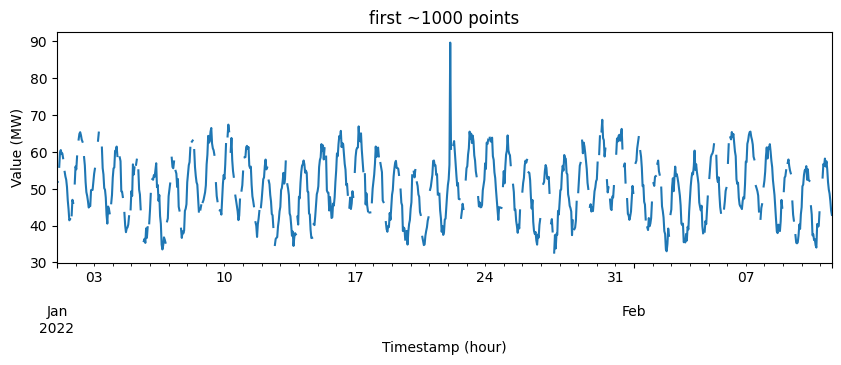

In [8]:
# GUIDED: visualize raw series using matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3))
df.iloc[:1000, 0].plot(title='first ~1000 points', xlabel='Timestamp (hour)', ylabel='Value (MW)')

## 2. Handling Missing Values in Time Series

Missing values in time series require special attention as they can affect temporal patterns. The appropriate strategy depends on your domain knowledge and the characteristics of the data:

- **Forward-fill**: Propagates the last valid observation forward (assumes persistence)
- **Backward-fill**: Uses next known values to fill gaps (useful for backfilling historical data)
- **Interpolation**: Creates smooth transitions between known values (linear, polynomial)

The choice should reflect the underlying physical or business process generating the data.

In [9]:
print('Missing values per column:\n', missing)

Missing values per column:
 value    2163
dtype: int64


In [10]:
# GUIDED: choose a missing value strategy and apply it
# TODO: Replace 'method' / 'limit' as needed or implement interpolation

filled = df.copy()

# Example 1: linear-based interpolation
# filled = filled.interpolate(method='linear')

# Example 2: forward/backward fill
filled = filled.ffill().bfill()

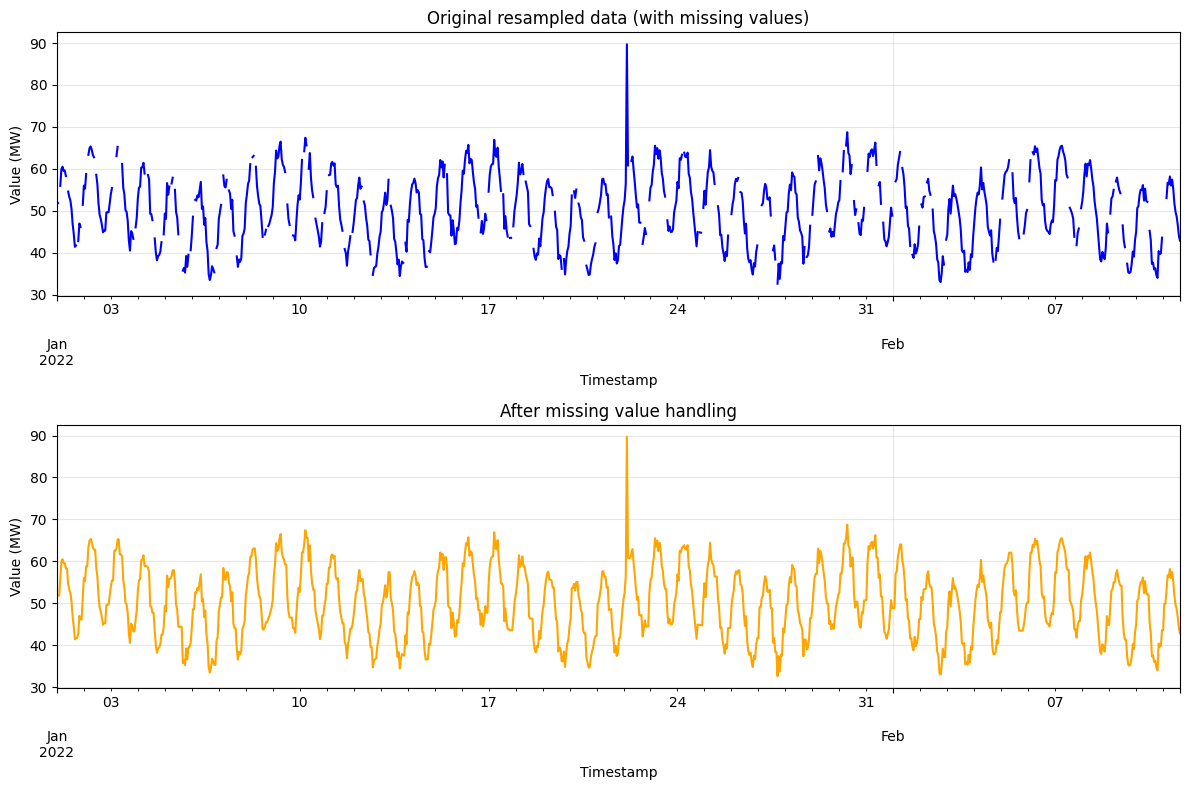

In [11]:
# EXERCISE: Compare filled vs non-filled data in subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot original resampled data (with missing values)
df.iloc[:1000, 0].plot(ax=ax1, title='Original resampled data (with missing values)', 
                               xlabel='Timestamp', ylabel='Value (MW)', color='blue')
ax1.grid(True, alpha=0.3)

# Plot filled data
filled.iloc[:1000, 0].plot(ax=ax2, title='After missing value handling', 
                           xlabel='Timestamp', ylabel='Value (MW)', color='orange')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# GUIDED: Check now many missing values remain
print('Missing values per column:\n', filled.isna().sum())

Missing values per column:
 value    0
dtype: int64


## 3. Resampling Time Series Data

**Goal:** Transform irregular or high-frequency data into a consistent, regular time grid.

1. Detect the original (native) sampling frequency
2. Choose an appropriate target frequency (hourly, daily, etc.)
   S: Seconds<br>
   min: Minutes<br>
   H: Hours<br>
   D: Day<br>
   W: Week<br>
   M: Month<br>
   Q: Quarter<br>
   Y: Year<br>

3. When downsampling (reducing the frequency), use the right aggregation method:
      - **Mean**: For measurements representing instantaneous values
      - **Sum**: For cumulative values that should be added (e.g., energy production)
      - **Last/First**: For snapshots or state-based values
   
4. When Upsampling (increasing the frequency), use the right filling method:
  - **Forward-fill**: Propagates the last valid observation forward (assumes persistence)
   - **Backward-fill**: Uses next known values to fill gaps (useful for backfilling historical data)
   - **Interpolation**: Creates smooth transitions between known values (linear, polynomial)


In [13]:
# GUIDED: Downsampling

#resampled = filled.resample('D').mean()        # for instantaneous data
resampled = filled.resample('D').sum()         # for cumulative data
#resampled = filled.resample('D').last()        # for state-based data

# GUIDED: Upsampling
#resampled = filled.resample('15min').ffill().dropna()    # forward-fill
#resampled = filled.resample('15min').bfill().dropna()     # backward-fill
#resampled = filled.resample('15min').interpolate(method='linear').dropna()  #

resampled.head(3)

,value
timestamp,
2022-01-01,1228.577304
2022-01-02,1323.271674
2022-01-03,1279.849213


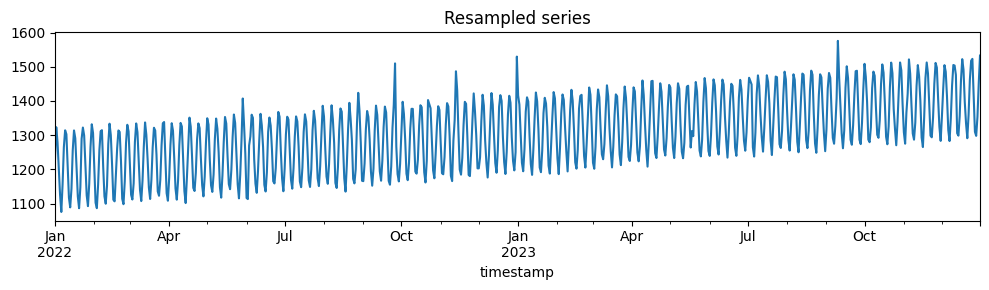

In [14]:
# GUIDED: visualize resampled series
plt.figure(figsize=(10, 3))
resampled.iloc[:1000, 0].plot(title=f'Resampled series')
plt.tight_layout()
plt.show()

<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Data Preparation</h2>

Complete the following tasks with the `de_energy_dataset.csv` dataset:
1. Load and visualize the raw data
2. Identify and handle missing values 
   - Try different filling methods (e.g., ffill, bfill, interpolate)

3. Resample the data
   - The data are monthly, try resampling to daily
   
   HINT: When upsampling always fill the missing values afterwards


This exercise will help reinforce the concepts of data cleaning and preparation for time series.
</div>

In [15]:
# Load exercise data

df_excercise = pd.read_csv("de_energy_dataset.csv")
#df_excercise['timestamp'] = ...

df_excercise['timestamp'] = pd.to_datetime(df_excercise['timestamp'])
df_excercise.index.freq = 'MS'
df_excercise = df_excercise.set_index('timestamp').sort_index()


In [16]:
df_excercise.head(6)

,Fossil,Wind,Solar
timestamp,,,
2016-01-01,37521.0,9771.0,702.0
2016-02-01,32023.0,10371.0,1350.0
2016-03-01,35256.0,6331.0,NaN
2016-04-01,30078.0,6235.0,4129.0
2016-05-01,27404.0,6445.0,5190.0
2016-06-01,27909.0,4434.0,5436.0


<Figure size 1000x300 with 0 Axes>

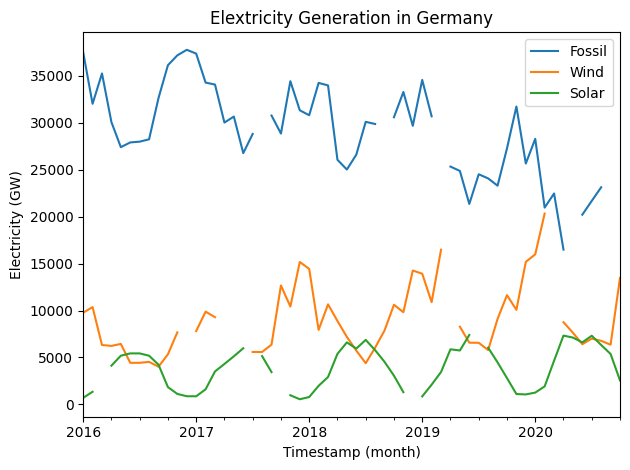

In [17]:
# GUIDED: visualize raw series: it should contain the different energy sources "Solar", "Wind", "Fossil"

plt.figure(figsize=(10, 3))
df_excercise.plot(title='Elextricity Generation in Germany', xlabel='Timestamp (month)', ylabel='Electricity (GW)')
plt.tight_layout()
plt.show()

In [18]:
# Check missing values

print('Missing values per column:\n', df_excercise.isna().sum())

Missing values per column:
 Fossil    5
Wind      5
Solar     5
dtype: int64


In [19]:
# handle missing values

filled_exercise = df_excercise.copy()

filled_exercise = filled_exercise.interpolate(method='linear')

In [20]:
print('Missing values per column:\n', filled_exercise.isna().sum())

Missing values per column:
 Fossil    0
Wind      0
Solar     0
dtype: int64


In [21]:
# Resampling: try frequency "D", "h", "W" and the appropriate aggregation / filling method

resampled_exercise = filled_exercise.resample("MS").interpolate(method='linear').dropna()

In [22]:
resampled_exercise

,Fossil,Wind,Solar
timestamp,,,
2016-01-01,37521.0,9771.0,702.0
2016-02-01,32023.0,10371.0,1350.0
2016-03-01,35256.0,6331.0,2739.5
2016-04-01,30078.0,6235.0,4129.0
2016-05-01,27404.0,6445.0,5190.0
2016-06-01,27909.0,4434.0,5436.0
2016-07-01,27991.0,4434.0,5436.0
2016-08-01,28239.0,4533.0,5191.0
2016-09-01,32634.0,4021.0,4233.0


<Figure size 1000x300 with 0 Axes>

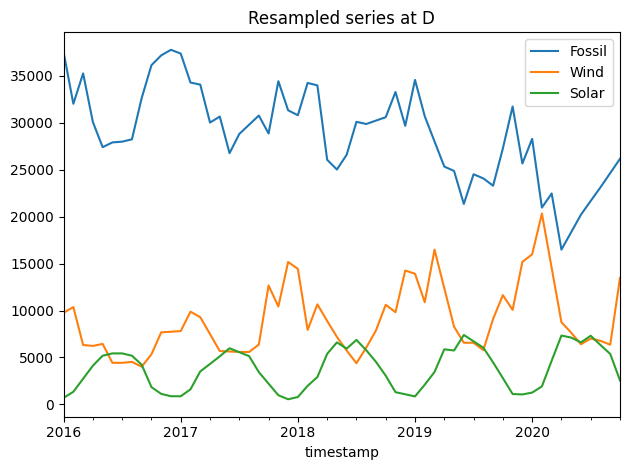

In [23]:
plt.figure(figsize=(10, 3))
resampled_exercise.plot(title=f'Resampled series at {"D"}')
plt.tight_layout()
plt.show()

## 4. Train/Validation/Test Split (for time-series)

Unlike traditional random splits used in other ML tasks, time series data requires **chronological splitting** to preserve temporal dependencies and avoid look-ahead bias.

- **Hold-Out Split**: Simple chronological division (e.g., 70% train, 30% test)
- **Rolling Window**: Multiple train/test splits that move forward in time
- **Expanding Window**: Growing training set with a rolling evaluation window

For this introductory block, we'll implement a basic Hold-Out split to establish the foundation for more advanced techniques.

In [24]:
# GUIDED: chronological split

len_train = int(len(resampled) * 0.7)

train = resampled.iloc[:len_train]
test = resampled.iloc[len_train:]

print('Split sizes:', len(train), len(test))
print('Ranges:')
print('Train:', train.index.min(), '→', train.index.max())
print('Test :', test.index.min(),  '→', test.index.max())

Split sizes: 510 220
Ranges:
Train: 2022-01-01 00:00:00 → 2023-05-25 00:00:00
Test : 2023-05-26 00:00:00 → 2023-12-31 00:00:00


## 5. Rescaling

Proper scaling is essential for many machine learning algorithms to work effectively with time series data.

- **Z-score (StandardScaler)**: `(x - mean) / std` - Centers data around zero with unit variance
- **Min-Max (MinMaxScaler)**: Scales data to a fixed range [0, 1]
- **Robust Scaler**: Uses median and IQR, making it resistant to outliers

### ⚠️ Important: Avoid Data Leakage
Always fit scalers **only on training data** to prevent information leakage from the validation and test sets. The code below demonstrates the effect of scaling but should not be applied to the entire dataset in a real forecasting scenario.

In [25]:
# GUIDED: Experiment with different scaling methods
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

scaler = StandardScaler()
# scaler = MinMaxScaler()
# scaler = RobustScaler()

train_scaled = pd.DataFrame(scaler.fit_transform(train), index=train.index, columns=train.columns)
test_scaled = pd.DataFrame(scaler.transform(test), index=test.index, columns=test.columns)


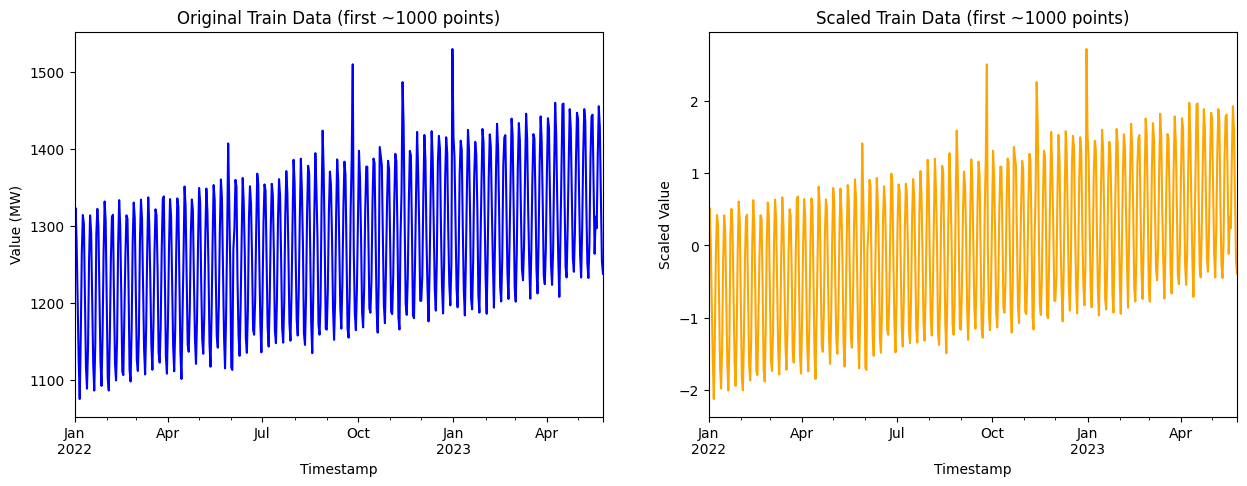

In [26]:
# Visualize original vs scaled data in subplots

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(15, 5))
train.iloc[:1000, 0].plot(ax=ax1, title='Original Train Data (first ~1000 points)', 
                          xlabel='Timestamp', ylabel='Value (MW)', color='blue')
train_scaled.iloc[:1000, 0].plot(ax=ax2, title='Scaled Train Data (first ~1000 points)', 
                            xlabel='Timestamp', ylabel='Scaled Value', color='orange')

plt.show()

In [27]:
# Saving the preprocessed data
train_scaled.to_parquet("train_preprocessed.parquet")
test_scaled.to_parquet("test_preprocessed.parquet")

<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Train-Validation-Test Split & Scaling</h2>

Apply what you've learned to the electricity dataset:
1. Split the resampled data into train, validation, and test sets using the Hold-Out Split method
2. Apply the most appropriate scaling method 
   - Try different scaling frequencies (e.g., zscore, MinMax)
   - Visualize random samples
3. Verify that scaling was properly applied without data leakage

This exercise will help you practice implementing a proper time series preprocessing pipeline.
</div>

In [28]:
# split the resampled electricity data in train validation test using the Hold-Out Split method
# 70% train, 15% val, 15% test

n_train_ex = int(len(resampled_exercise)*0.7)

train_ex = resampled_exercise.iloc[:n_train_ex]
test_ex = resampled_exercise.iloc[n_train_ex:]

print('Split sizes:', len(train_ex), len(test_ex))
print('Ranges:')
print('Train:', train_ex.index.min(), '→', train_ex.index.max())
print('Test :', test_ex.index.min(),  '→', test_ex.index.max())



Split sizes: 40 18
Ranges:
Train: 2016-01-01 00:00:00 → 2019-04-01 00:00:00
Test : 2019-05-01 00:00:00 → 2020-10-01 00:00:00


In [29]:
# - rescale the data using the most appropriate method

scaler = StandardScaler()

train_scaled_ex = pd.DataFrame(scaler.fit_transform(train_ex), index=train_ex.index, columns=train_ex.columns)
test_scaled_ex = pd.DataFrame(scaler.transform(test_ex), index=test_ex.index, columns=test_ex.columns)

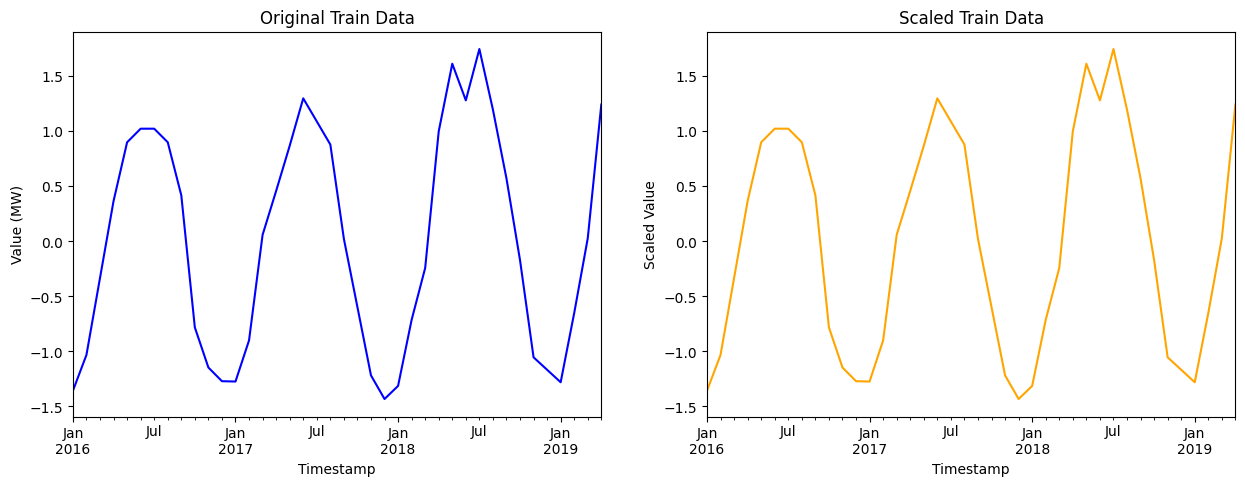

In [30]:
# Visualize original vs scaled data in subplots

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(15, 5))
train_scaled_ex["Solar"].iloc[:1000].plot(ax=ax1, title='Original Train Data', 
                          xlabel='Timestamp', ylabel='Value (MW)', color='blue')
train_scaled_ex["Solar"].iloc[:1000].plot(ax=ax2, title='Scaled Train Data', 
                            xlabel='Timestamp', ylabel='Scaled Value', color='orange')

plt.show()

In [31]:
# Saving the preprocessed data (save data with no resampling "resampled_exercise = filled_exercise")
train_scaled_ex.to_parquet("train_preprocessed_ex.parquet")
test_scaled_ex.to_parquet("test_preprocessed_ex.parquet")

## ✅ Summary

### What You've Accomplished:
- Loaded and performed quality checks on time series data
- Implemented strategies for handling missing values and resampling
- Created time-aware train/validation/test splits
- Applied proper scaling techniques while avoiding data leakage

These preprocessing steps are crucial for achieving good performance with any time series forecasting model.